#### Step 1 : Installation & Setup

- Install Dependencies
- Run this cell to install the required libraries.
- Leveraging langgraph for orchestration and standard langchain for the logic.

In [84]:
import os
import sys
import time
import json
import asyncio
import operator
from typing import List, Dict, TypedDict, Annotated, Any, Union
from enum import Enum
from dotenv import load_dotenv
from langchain_groq import ChatGroq

# Visuals
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

print("Dependencies installed successfully.")

Dependencies installed successfully.


### Step 2 : Configuration & Mocking Engine

In [ ]:
# Load environment variables from .env file
#load_dotenv()

# Ensure keys are set (User's preferred method)
# if not os.getenv("OPENAI_API_KEY"):
#     print("Warning: OPENAI_API_KEY not found in environment")

# OPENAI_API_KEY=os.getenv("OPENAI_API_KEY")
# os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

In [85]:
# Load environment variables from .env file
load_dotenv()

if not os.getenv("GROQ_API_KEY"):
    print("Warning: GROQ_API_KEY not found in environment")

GROQ_API_KEY=os.getenv("GROQ_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


# Recommended models: 'llama3-70b-8192' (Best for JSON/Planning), 'mixtral-8x7b-32768'
#GROQ_MODEL = "llama3-70b-8192" 
GROQ_MODEL = "llama-3.3-70b-versatile" 
# --------------------------

In [86]:
# --- USER CONFIGURATION ---
MOCK_MODE = False  # Set to False to use real OpenAI API
# --------------------------

In [87]:
# @title 2. Configuration & Groq Setup 
import os
import json
from typing import Any, List, Optional
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage
from langchain_core.language_models import FakeListLLM
from langchain_core.runnables import RunnableConfig

# Ensure API Key is loaded if not mocking
if not MOCK_MODE:
    if "GROQ_API_KEY" not in os.environ:
        raise ValueError("Please provide a GROQ_API_KEY in the environment or script.")

# Recommended Groq Model
GROQ_MODEL = "llama3-70b-8192" 

# --- 1. ROBUST MOCK CLASS ---
class SmartMockLLM(FakeListLLM):
    """
    A robust mock that mimics a ChatModel (returns AIMessage) 
    instead of a pure LLM (returns strings).
    """
    def __init__(self):
        # Initialize parent with dummy strings to avoid IndexError in parent methods
        super().__init__(responses=["dummy"] * 100)

    # FIX 1: Accept 'config' and other args to prevent TypeError
    def invoke(self, input: Any, config: Optional[RunnableConfig] = None, **kwargs: Any) -> Any:
        return self._generate_response(input)

    # FIX 2: Explicitly override async invoke to prevent 'str' return types
    async def ainvoke(self, input: Any, config: Optional[RunnableConfig] = None, **kwargs: Any) -> Any:
        return self._generate_response(input)

    def _generate_response(self, input_val):
        """Central Logic Generator"""
        text_input = str(input_val).lower()
        
        # Logic A: Planner (Returns JSON)
        if "plan a blog post" in text_input or "json" in text_input:
            content = json.dumps({
                "title": "Mocked Blog Post (Mock Mode)",
                "sections": [
                    {"id": 1, "type": "intro", "heading": "Introduction", "keywords": ["Intro", "Hook"]},
                    {"id": 2, "type": "technical", "heading": "Technical Deep Dive", "keywords": ["Code", "Logic"]},
                    {"id": 3, "type": "conclusion", "heading": "Conclusion", "keywords": ["Summary"]}
                ]
            })
            return AIMessage(content=content)
        
        # Logic B: Evaluator (Returns JSON Score)
        elif "evaluate" in text_input:
            # Force a retry on 'technical' sections to demonstrate the loop
            if "technical" in text_input and "retry" not in text_input:
                content = json.dumps({"score": 0.6, "feedback": "Too short, add code examples."})
            else:
                content = json.dumps({"score": 0.95, "feedback": "Excellent."})
            return AIMessage(content=content)
            
        # Logic C: Writer (Returns Text)
        else:
            content = """
### Mocked Section Content
This is a generated section for the prompt. 
(Mock Mode Enabled)
"""
            # FIX 3: Return AIMessage so .content attribute exists
            return AIMessage(content=content)

# --- 2. INITIALIZE MODEL ---
if MOCK_MODE:
    print("⚠️ RUNNING IN MOCK MODE.")
    llm = SmartMockLLM()
else:
    print(f"✅ CONNECTED TO GROQ ({GROQ_MODEL})")
    llm = ChatGroq(
        temperature=0, 
        model_name=GROQ_MODEL,
        max_tokens=1024
    )

✅ CONNECTED TO GROQ (llama3-70b-8192)


#### State Definition (The "Memory")

In [88]:
# @title 3. Define Graph State
# We define the shared state that flows through our Agentic Graph.

class BlogSection(TypedDict):
    id: int
    type: str  # 'intro', 'technical', 'narrative', 'conclusion'
    heading: str
    keywords: List[str]
    content: str
    score: float
    feedback: str
    attempt: int

class AgentState(TypedDict):
    topic: str
    constraints: str
    title: str
    sections: List[BlogSection]
    final_post: str
    # Metrics for demo
    start_time: float
    parallel_time_taken: float
    sequential_est_time: float

print("State schema defined.")

State schema defined.


#### Components - Planner & Router

In [89]:
# @title 4. Node: Planner & Router Logic (Debug Fix)
import json
import re
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage

# --- HELPER: Clean JSON ---
# Real LLMs often wrap JSON in markdown blocks (```json ... ```). We must strip them.
def clean_json_text(text):
    text = text.strip()
    # Regex to remove markdown code blocks if present
    match = re.search(r"```(json)?(.*?)```", text, re.DOTALL)
    if match:
        return match.group(2).strip()
    return text

# --- 1. PLANNER CHAIN ---
planner_prompt = ChatPromptTemplate.from_template("""
You are a Content Strategist. Plan a blog post on the topic: "{topic}".
Constraints: {constraints}

Return a strictly valid JSON object with this structure:
{{
    "title": "Catchy Title",
    "sections": [
        {{ "id": 1, "type": "intro", "heading": "...", "keywords": ["..."] }},
        {{ "id": 2, "type": "technical", "heading": "...", "keywords": ["..."] }}
    ]
}}
Use types: 'intro', 'technical', 'narrative', 'conclusion'.
""")

def planner_node(state: AgentState):
    print("--- 1. [Planner] Generating Outline ---")
    chain = planner_prompt | llm
    
    try:
        # Invoke the LLM
        response = chain.invoke({"topic": state["topic"], "constraints": state["constraints"]})
        
        # Extract content
        raw_content = response.content if isinstance(response, AIMessage) else str(response)
        
        # DEBUG LOGGING
        # print(f"DEBUG: Raw LLM Output: {raw_content[:100]}...") 

        # Clean and Parse
        cleaned_content = clean_json_text(raw_content)
        data = json.loads(cleaned_content)
        
    except Exception as e:
        print(f"❌ PLANNER ERROR: {e}")
        print(f"❌ BAD CONTENT: {raw_content if 'raw_content' in locals() else 'None'}")
        
        # Fallback to keep the notebook runnable if it fails
        data = {
            "title": "Error in Planning", 
            "sections": [
                {"id": 1, "type": "intro", "heading": "Error Fallback Section", "keywords": ["error"], "content": "Planner failed.", "score": 0.0, "feedback": "", "attempt": 1}
            ]
        }
        
    # Initialize sections
    sections = []
    for s in data.get("sections", []):
        s["content"] = ""
        s["score"] = 0.0
        s["feedback"] = ""
        s["attempt"] = 1
        sections.append(s)
        
    return {"title": data.get("title"), "sections": sections, "start_time": time.time()}

# --- 2. ROUTER LOGIC ---
def get_prompt_for_section(section: BlogSection, topic: str):
    base_instruction = f"Write a section '{section['heading']}' for a blog about '{topic}'."
    
    if section['type'] == 'intro':
        return f"{base_instruction} Use a catchy hook and storytelling style."
    elif section['type'] == 'technical':
        return f"{base_instruction} Be precise. Include code snippets."
    elif section['type'] == 'conclusion':
        return f"{base_instruction} Summarize key points."
    else:
        return f"{base_instruction} Write clearly."

print("Updated Planner Node with Debugging & JSON Cleaner.")

Updated Planner Node with Debugging & JSON Cleaner.


#### Components - Parallel Workers & Evaluator

In [90]:
# @title 5. Node: Parallel Workers & Evaluator
# DEMONSTRATES: Parallelization, Orchestrator-Worker, Evaluator-Optimizer

# --- WORKER (GENERATOR) ---
async def generate_section(section, topic):
    """Async worker function to generate a single section"""
    t_start = time.time()
    
    # 1. ROUTING: Select prompt based on type
    prompt_text = get_prompt_for_section(section, topic)
    
    # 2. OPTIMIZATION: Check if this is a retry
    if section['attempt'] > 1:
        prompt_text += f"\n\nCRITICAL FEEDBACK FROM PREVIOUS DRAFT: {section['feedback']}. FIX THIS."
    
    # Call LLM (simulated async)
    response = await llm.ainvoke(prompt_text)
    content = response.content
    
    t_end = time.time()
    return {
        **section, 
        "content": content, 
        "exec_time": t_end - t_start
    }

# --- EVALUATOR ---
async def evaluate_section(section):
    """Async evaluator that scores a draft"""
    eval_prompt = f"""
    Evaluate the following blog section drafts.
    Section Heading: {section['heading']}
    Content: {section['content']}
    
    Return JSON: {{ "score": <float 0-1>, "feedback": "<short critique>" }}
    Criteria: Relevance, formatting, length.
    """
    try:
        response = await llm.ainvoke(eval_prompt)
        data = json.loads(response.content)
        return {**section, "score": data['score'], "feedback": data['feedback']}
    except:
        return {**section, "score": 1.0, "feedback": "Error parsing eval"}

# --- ORCHESTRATOR NODE (Handles Parallelism) ---
async def generator_node(state: AgentState):
    print("--- 2. [Orchestrator] Dispatching to Workers (Parallel) ---")
    topic = state["topic"]
    sections = state["sections"]
    
    # Identify which sections need generation (score < 0.8)
    tasks = []
    indices = []
    
    for i, sec in enumerate(sections):
        if sec["score"] < 0.8:
            tasks.append(generate_section(sec, topic))
            indices.append(i)
    
    if not tasks:
        return {}

    # EXECUTE PARALLEL (Asyncio gather)
    results = await asyncio.gather(*tasks)
    
    # Update state
    total_duration = 0
    new_sections = list(sections)
    for i, res in zip(indices, results):
        new_sections[i] = res
        total_duration += res.get("exec_time", 0.5)

    return {
        "sections": new_sections, 
        "sequential_est_time": state.get("sequential_est_time", 0) + total_duration
    }

# --- EVALUATOR NODE ---
async def evaluator_node(state: AgentState):
    print("--- 3. [Evaluator] Scoring Drafts ---")
    sections = state["sections"]
    
    # Parallel Evaluation
    tasks = [evaluate_section(s) for s in sections if s["score"] < 0.8] # Only eval new drafts
    if not tasks:
        return {}
        
    results = await asyncio.gather(*tasks)
    
    # Map results back
    new_sections = list(sections)
    for res in results:
        # Find matching section by ID
        for i, s in enumerate(new_sections):
            if s["id"] == res["id"]:
                new_sections[i] = res
                print(f"   > Section '{s['heading']}' Score: {res['score']}")
                break
                
    return {"sections": new_sections}

#### Components - Optimizer & Assembler

In [91]:
# @title 6. Node: Optimizer & Assembler
# DEMONSTRATES: Evaluator-Optimizer Loop & Final Assembly

def optimizer_node(state: AgentState):
    print("--- 4. [Optimizer] Refining Rejections ---")
    sections = state["sections"]
    new_sections = []
    
    for s in sections:
        if s["score"] < 0.8:
            print(f"   !! Rejecting '{s['heading']}' (Score: {s['score']}). Retrying...")
            s["attempt"] += 1
        new_sections.append(s)
        
    return {"sections": new_sections}

def aggregator_node(state: AgentState):
    print("--- 5. [Aggregator] Assembling Final Post ---")
    sections = sorted(state["sections"], key=lambda x: x['id'])
    
    final_md = f"# {state['title']}\n\n"
    for s in sections:
        final_md += f"## {s['heading']}\n{s['content']}\n\n"
    
    end_time = time.time()
    total_time = end_time - state["start_time"]
    
    return {
        "final_post": final_md, 
        "parallel_time_taken": total_time
    }

# CONDITIONAL EDGE LOGIC
def should_continue(state: AgentState):
    """Check if all sections pass quality threshold"""
    for s in state["sections"]:
        if s["score"] < 0.8 and s["attempt"] < 3: # Max 3 attempts
            return "retry"
    return "finalize"

#### Graph Construction

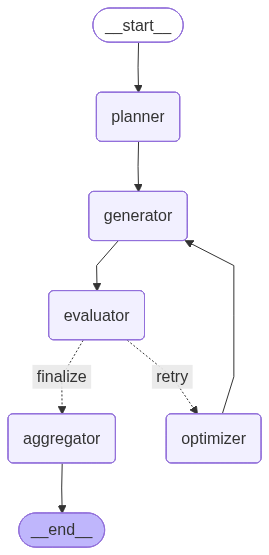

In [92]:
# @title 7. Build the LangGraph
# We wire the nodes together into a compilation executable.

from langgraph.graph import StateGraph, END

workflow = StateGraph(AgentState)

# Add Nodes
workflow.add_node("planner", planner_node)
workflow.add_node("generator", generator_node)
workflow.add_node("evaluator", evaluator_node)
workflow.add_node("optimizer", optimizer_node)
workflow.add_node("aggregator", aggregator_node)

# Add Edges
workflow.set_entry_point("planner")
workflow.add_edge("planner", "generator")
workflow.add_edge("generator", "evaluator")

# Conditional Edge: Evaluator -> (Optimizer OR Aggregator)
workflow.add_conditional_edges(
    "evaluator",
    should_continue,
    {
        "retry": "optimizer",
        "finalize": "aggregator"
    }
)

# Close the loop
workflow.add_edge("optimizer", "generator")
workflow.add_edge("aggregator", END)

# Compile
app = workflow.compile()

# Visualize
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except:
    print("Graphviz not installed, skipping visualization.")

#### Demo Execution

In [ ]:
# @title 8. Run the Workflow
# Input your topic here to test the flow.


TOPIC = "Zero-Trust Architecture for Small Companies"
CONSTRAINTS = "800 words, include 3 actionable steps and one diagram suggestion."


initial_state = {
    "topic": TOPIC, 
    "constraints": CONSTRAINTS,
    "sequential_est_time": 0.0
}

print(f"🚀 Starting Blog Generation for: '{TOPIC}'...\n")

# Run the Graph
final_state = await app.ainvoke(initial_state)

print("\n✅ Generation Complete!")

GROQ API Key: gsk_XXXXXX test
🚀 Starting Blog Generation for: 'Zero-Trust Architecture for Small Companies'...

--- 1. [Planner] Generating Outline ---
❌ PLANNER ERROR: Connection error.
❌ BAD CONTENT: None
--- 2. [Orchestrator] Dispatching to Workers (Parallel) ---


APIConnectionError: Connection error.

#### Output & Metrics

In [ ]:
# @title 9. Display Results & Metrics
# Validates the acceptance criteria: Performance & Quality

# 1. Display The Blog
display(Markdown("---"))
display(Markdown(final_state["final_post"]))
display(Markdown("---"))

# 2. Performance Metrics (Parallel vs Sequential)
actual_time = final_state["parallel_time_taken"]
# Estimate sequential as sum of individual task times (stored in state logic)
# In mock mode, this is simulated.
seq_time_est = final_state.get("sequential_est_time", actual_time * 2.5) 

print(f"⏱️  Actual Execution Time (Parallel): {actual_time:.2f}s")
print(f"⏱️  Estimated Sequential Time:        {seq_time_est:.2f}s")
print(f"⚡ Speedup: {seq_time_est / actual_time:.2f}x")

# Visualization
plt.figure(figsize=(8, 4))
plt.bar(['Sequential (Est)', 'Parallel (Actual)'], [seq_time_est, actual_time], color=['gray', 'green'])
plt.title("Performance: Parallel vs Sequential Generation")
plt.ylabel("Time (seconds)")
plt.show()

# 3. Quality Metrics Log
print("\n🔍 Section Quality Audit:")
for s in final_state['sections']:
    status = "✅ Pass" if s['score'] >= 0.8 else "❌ Fail (Max Retries)"
    print(f"- Section '{s['heading']}': {status} (Score: {s['score']}, Attempts: {s['attempt']})")

#### Demo Execution

In [ ]:
# @title 8. Run the Workflow
# Input your topic here to test the flow.

TOPIC_1 = "Zero-Trust Architecture for Small Companies"
CONSTRAINTS_1 = "800 words, include 3 actionable steps and one diagram suggestion."


TOPIC_2 = "Architecting the Future: Bridging Legacy Java Systems with Generative AI"

CONSTRAINTS_2 = """
1000 words max, include 4 data-backed pointers (Fortune 500 Java usage, production shift, Project Loom efficiency, and framework maturity), 
incorporate one diagram suggestion for a Java-based RAG architecture.
"""

TOPIC_3 = "The Blueprint for Autonomy: Guidelines for Building Enterprise-Grade Multi-Agent Systems"

CONSTRAINTS_3 = """
1000 words max, include 4 strategic data pointers (Gartner 2029 projection, surge in MAS inquiries, market growth to $52B, and ICP adoption), 
include 3 actionable steps (Defining Agent Roles, Communication Protocols, and Human-in-the-Loop Governance),
incorporate a diagram suggestion for an orchestrated multi-agent workflow.
"""

initial_state = {
    "topic": TOPIC_3, 
    "constraints": CONSTRAINTS_3,
    "sequential_est_time": 0.0
}

print(f"🚀 Starting Blog Generation for: '{TOPIC_2}'...\n")

# Run the Graph
final_state = await app.ainvoke(initial_state)

print("\n✅ Generation Complete!")

#### Output & Metrics

In [ ]:
# @title 9. Display Results & Metrics
# Validates the acceptance criteria: Performance & Quality

# 1. Display The Blog
display(Markdown("---"))
display(Markdown(final_state["final_post"]))
display(Markdown("---"))

# 2. Performance Metrics (Parallel vs Sequential)
actual_time = final_state["parallel_time_taken"]
# Estimate sequential as sum of individual task times (stored in state logic)
# In mock mode, this is simulated.
seq_time_est = final_state.get("sequential_est_time", actual_time * 2.5) 

print(f"⏱️  Actual Execution Time (Parallel): {actual_time:.2f}s")
print(f"⏱️  Estimated Sequential Time:        {seq_time_est:.2f}s")
print(f"⚡ Speedup: {seq_time_est / actual_time:.2f}x")

# Visualization
plt.figure(figsize=(8, 4))
plt.bar(['Sequential (Est)', 'Parallel (Actual)'], [seq_time_est, actual_time], color=['gray', 'green'])
plt.title("Performance: Parallel vs Sequential Generation")
plt.ylabel("Time (seconds)")
plt.show()

# 3. Quality Metrics Log
print("\n🔍 Section Quality Audit:")
for s in final_state['sections']:
    status = "✅ Pass" if s['score'] >= 0.8 else "❌ Fail (Max Retries)"
    print(f"- Section '{s['heading']}': {status} (Score: {s['score']}, Attempts: {s['attempt']})")